ВАРИАНТ 1

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pnd
import time

In [57]:
data1 = pnd.read_csv('task11.csv')
data2 = pnd.read_csv('task21.csv')

In [58]:
data1
print(data1.head())

          x1         x2  target
0   9.249743  12.797165       0
1  26.118513  13.936663       1
2   8.696962  11.116652       0
3  21.614879   6.138127       1
4  11.247285  12.849175       0


In [59]:
x = data1.drop(columns=['target'])
y = data1['target']
y

0      0
1      1
2      0
3      1
4      0
      ..
395    1
396    0
397    1
398    0
399    1
Name: target, Length: 400, dtype: int64

In [60]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [61]:
svc_model = SVC(kernel='linear')

In [62]:
start = time.time()
svc_model.fit(x_train, y_train)
end = time.time() - start

In [63]:
y_pred = svc_model.predict(x_test)
print(f'точность модели: {accuracy_score(y_test, y_pred)*100}%')
print(f'Время обучения: {end}')

точность модели: 100.0%
Время обучения: 0.0020780563354492188


In [64]:
# 1. Определяем диапазоны для x1 и x2 (с небольшим запасом)
x1_min, x1_max = x_train['x1'].min() - 1, x_train['x1'].max() + 1
x2_min, x2_max = x_train['x2'].min() - 1, x_train['x2'].max() + 1

# 2. Создаём равномерные распределения (linspace)
A = np.linspace(x1_min, x1_max, 500)  # для x1
B = np.linspace(x2_min, x2_max, 500)  # для x2

# 3. Создаём координатную сетку (meshgrid)
B1, A1 = np.meshgrid(B, A)

# 4. Объединяем в матрицу координат (vstack + ravel + transpose)
xy = np.vstack([A1.ravel(), B1.ravel()]).T

# 5. Получаем оценки функции решения (decision_function)
Z = svc_model.decision_function(xy).reshape(A1.shape)

d:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


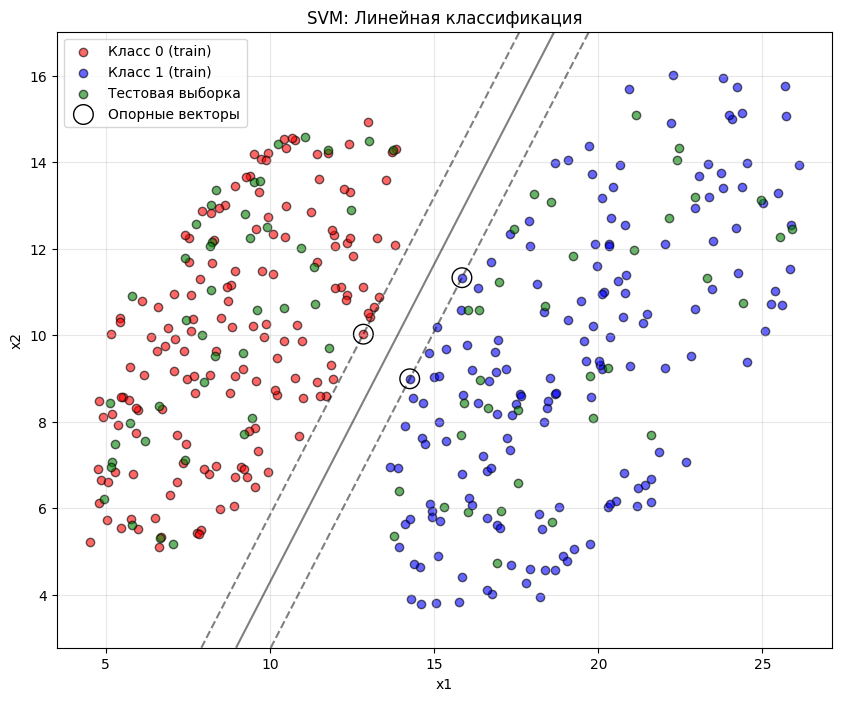

In [65]:
plt.figure(figsize=(10, 8))

# Пункт 9: Обучающая выборка (красный и синий для разных классов)
plt.scatter(x_train[y_train == 0]['x1'], x_train[y_train == 0]['x2'], 
            c='red', label='Класс 0 (train)', alpha=0.6, edgecolors='k')
plt.scatter(x_train[y_train == 1]['x1'], x_train[y_train == 1]['x2'], 
            c='blue', label='Класс 1 (train)', alpha=0.6, edgecolors='k')

# Пункт 10: Тестовая выборка (зелёный цвет)
plt.scatter(x_test['x1'], x_test['x2'], 
            c='green', label='Тестовая выборка', alpha=0.6, edgecolors='k')

# Пункт 11: Разделяющая гиперплоскость и зазоры
# levels=[-1, 0, 1]: 0 - гиперплоскость, -1 и 1 - границы зазора
plt.contour(A1, B1, Z, colors='k', levels=[-1, 0, 1], 
            alpha=0.5, linestyles=['--', '-', '--'])

# Пункт 12: Опорные векторы (обводим окружностями)
support_vectors = svc_model.support_vectors_
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], 
            s=200, facecolors='none', edgecolors='black', 
            linewidths=1, label='Опорные векторы')

# Оформление
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('SVM: Линейная классификация')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('svm_visualization_task11.png', dpi=300)  # Пункт 16: сохранение для отчёта
plt.show()

In [66]:
accuracies = []
r_state = [40, 40, 59, 32, 26, 30, 81, 47, 35, 88]
for i in range(10):
    # 1. Разбиение с разным random_state
    x_tr, x_te, y_tr, y_te = train_test_split(x, y, test_size=0.2, random_state=r_state[i])
    
    # 2. Обучение модели
    model = SVC(kernel='linear')
    model.fit(x_tr, y_tr)
    
    # 3. Предсказание (Пункт 13)
    y_pred = model.predict(x_te)
    
    # 4. Оценка точности (Пункт 14)
    acc = accuracy_score(y_te, y_pred) * 100
    accuracies.append(acc)
    
    print(f"Запуск {i+1}: Точность = {acc:.2f}%")

# 5. Статистика (Пункт 15)
mean_acc = np.mean(accuracies)
std_acc = np.std(accuracies)

print(f"\n{'='*50}")
print(f"Средняя точность: {mean_acc:.2f}%")
print(f"Среднеквадратичное отклонение: {std_acc:.2f}%")
print(f"{'='*50}")

Запуск 1: Точность = 100.00%
Запуск 2: Точность = 100.00%
Запуск 3: Точность = 100.00%
Запуск 4: Точность = 100.00%
Запуск 5: Точность = 100.00%
Запуск 6: Точность = 100.00%
Запуск 7: Точность = 100.00%
Запуск 8: Точность = 100.00%
Запуск 9: Точность = 100.00%
Запуск 10: Точность = 100.00%

Средняя точность: 100.00%
Среднеквадратичное отклонение: 0.00%


Обработка данных файла task21.csv

In [67]:
data2
print(data2.head())

         x1         x2  target
0  5.838053  13.737139       0
1  4.776516  11.451402       1
2  6.257577  13.754141       0
3  6.583901  11.589449       1
4  4.466747  16.340799       0


In [68]:
x = data2.drop(columns=['target'])
y = data2['target']
y


0      0
1      1
2      0
3      1
4      0
      ..
395    1
396    0
397    1
398    0
399    1
Name: target, Length: 400, dtype: int64

In [69]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
svc_model = SVC(kernel='linear')


In [70]:
start = time.time()
svc_model.fit(x_train, y_train)
end = time.time() - start


In [71]:
y_pred = svc_model.predict(x_test)
print(f'точность модели: {accuracy_score(y_test, y_pred)*100}%')
print(f'Время обучения: {end}')


точность модели: 98.75%
Время обучения: 0.0033206939697265625


d:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


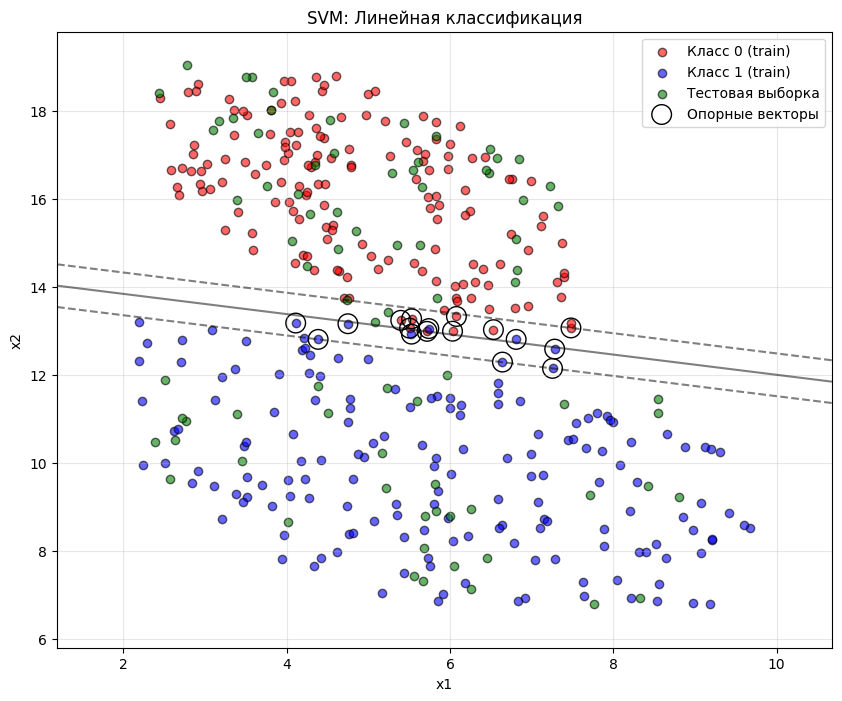

In [ ]:
# 1. Определяем диапазоны для x1 и x2 (с небольшим запасом)
x1_min, x1_max = x_train['x1'].min() - 1, x_train['x1'].max() + 1
x2_min, x2_max = x_train['x2'].min() - 1, x_train['x2'].max() + 1

# 2. Создаём равномерные распределения (linspace)
A = np.linspace(x1_min, x1_max, 500)  # для x1
B = np.linspace(x2_min, x2_max, 500)  # для x2

# 3. Создаём координатную сетку (meshgrid)
B1, A1 = np.meshgrid(B, A)

# 4. Объединяем в матрицу координат (vstack + ravel + transpose)
xy = np.vstack([A1.ravel(), B1.ravel()]).T

# 5. Получаем оценки функции решения (decision_function)
Z = svc_model.decision_function(xy).reshape(A1.shape)
plt.figure(figsize=(10, 8))

# Пункт 9: Обучающая выборка (красный и синий для разных классов)
plt.scatter(x_train[y_train == 0]['x1'], x_train[y_train == 0]['x2'], 
            c='red', label='Класс 0 (train)', alpha=0.6, edgecolors='k')
plt.scatter(x_train[y_train == 1]['x1'], x_train[y_train == 1]['x2'], 
            c='blue', label='Класс 1 (train)', alpha=0.6, edgecolors='k')

# Пункт 10: Тестовая выборка (зелёный цвет)
plt.scatter(x_test['x1'], x_test['x2'], 
            c='green', label='Тестовая выборка', alpha=0.6, edgecolors='k')

# Пункт 11: Разделяющая гиперплоскость и зазоры
# levels=[-1, 0, 1]: 0 - гиперплоскость, -1 и 1 - границы зазора
plt.contour(A1, B1, Z, colors='k', levels=[-1, 0, 1], 
            alpha=0.5, linestyles=['--', '-', '--'])

# Пункт 12: Опорные векторы (обводим окружностями)
support_vectors = svc_model.support_vectors_
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], 
            s=200, facecolors='none', edgecolors='black', 
            linewidths=1, label='Опорные векторы')

# Оформление
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('SVM: Линейная классификация')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('svm_visualization_task21.png', dpi=300)  # Пункт 16: сохранение для отчёта
plt.show()


In [73]:
accuracies = []
r_state = [40, 40, 59, 32, 26, 30, 81, 47, 35, 88]
for i in range(10):
    # 1. Разбиение с разным random_state
    x_tr, x_te, y_tr, y_te = train_test_split(x, y, test_size=0.2, random_state=r_state[i])
    
    # 2. Обучение модели
    model = SVC(kernel='linear')
    model.fit(x_tr, y_tr)
    
    # 3. Предсказание (Пункт 13)
    y_pred = model.predict(x_te)
    
    # 4. Оценка точности (Пункт 14)
    acc = accuracy_score(y_te, y_pred) * 100
    accuracies.append(acc)
    
    print(f"Запуск {i+1}: Точность = {acc:.2f}%")

# 5. Статистика (Пункт 15)
mean_acc = np.mean(accuracies)
std_acc = np.std(accuracies)

print(f"\n{'='*50}")
print(f"Средняя точность: {mean_acc:.2f}%")
print(f"Среднеквадратичное отклонение: {std_acc:.2f}%")
print(f"{'='*50}")

Запуск 1: Точность = 100.00%
Запуск 2: Точность = 100.00%
Запуск 3: Точность = 97.50%
Запуск 4: Точность = 98.75%
Запуск 5: Точность = 98.75%
Запуск 6: Точность = 98.75%
Запуск 7: Точность = 100.00%
Запуск 8: Точность = 97.50%
Запуск 9: Точность = 98.75%
Запуск 10: Точность = 97.50%

Средняя точность: 98.75%
Среднеквадратичное отклонение: 0.97%
